In [ ]:
import numpy as np
times_path = r"01_A_CPU0_DB1206_FE_CPUTx_JT4K43_SSCON_CH1P_CH3N_110us.csv"
crossing_times = np.loadtxt(times_path, delimiter=",", dtype=float).reshape(-1)
print(crossing_times.shape)

(109849,)


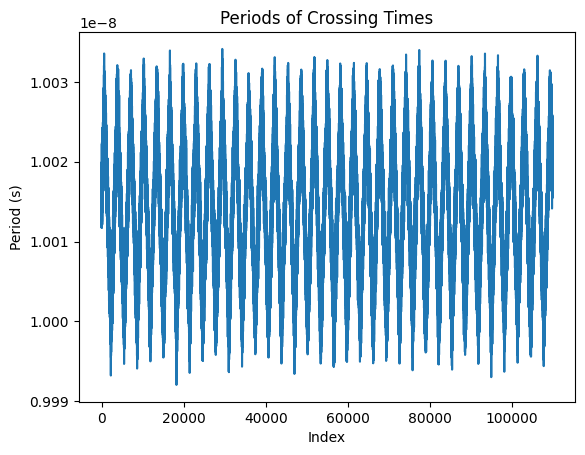

Frequency: 99862269.12011416


In [30]:
import matplotlib.pyplot as plt
periods = np.diff(crossing_times)
plt.plot(periods)
plt.xlabel("Index")
plt.ylabel("Period (s)")
plt.title("Periods of Crossing Times")
plt.show()
print(f"Frequency: {1/np.mean(periods)}")

In [31]:
edge_index = np.arange(len(crossing_times))
fitted_period, fitted_intercept = np.polyfit(edge_index, crossing_times, 1)
fitted_freq = 1 / fitted_period
print(f"Fitted frequency: {fitted_freq}")

Fitted frequency: 99863202.09269634


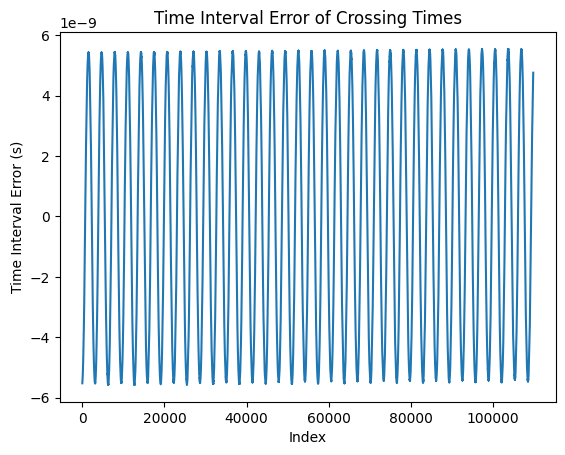

In [32]:
ideal_crossing_times = fitted_intercept + fitted_period * edge_index
tie = crossing_times - ideal_crossing_times
plt.plot(tie)
plt.xlabel("Index")
plt.ylabel("Time Interval Error (s)")
plt.title("Time Interval Error of Crossing Times")
plt.show()

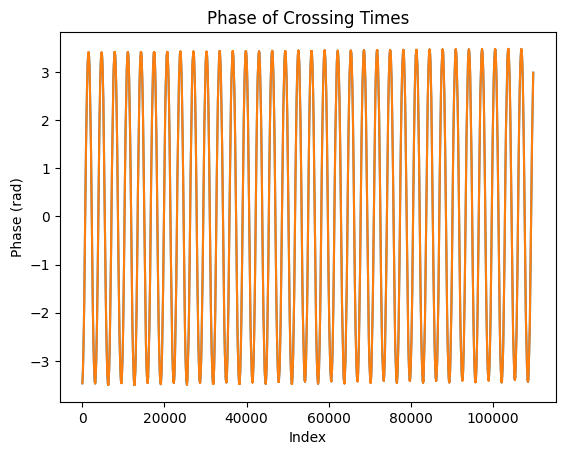

In [33]:
phi = tie * 2 * np.pi * fitted_freq 
plt.plot(phi)
plt.plot(phi - np.mean(phi))
plt.xlabel("Index")
plt.ylabel("Phase (rad)")
plt.title("Phase of Crossing Times")
plt.show()

In [34]:
phi_fft = np.fft.rfft(phi)
freqs = np.fft.rfftfreq(len(phi), d=1/fitted_freq)
psd = (np.abs(phi_fft)**2) / (27e6 * len(phi))
if len(psd) % 2 == 0:
    psd[1:-1] *= 2.0
else:
    psd[1:] *= 2.0
l_psd = 10 * np.log10(psd/2)

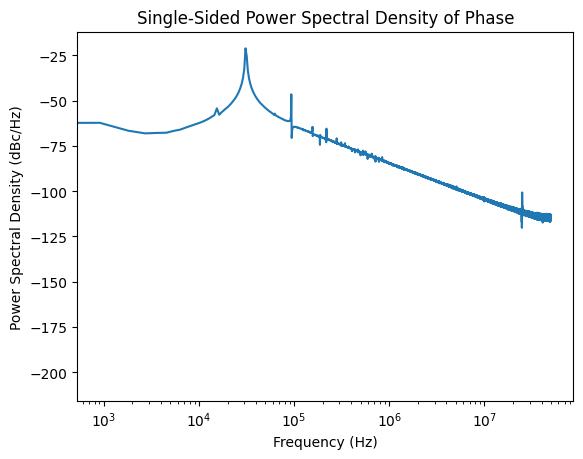

In [35]:
plt.plot(freqs, l_psd)
plt.xscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dBc/Hz)")
plt.title("Single-Sided Power Spectral Density of Phase")
plt.show()